In [1]:
# моделирование движения
# электрического заряда
# в постоянном магнитном поле

# Ячейка № 1
# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание вектора безразмерной
# напряженности магнитного поля
B = np.array([0, 0, 1])


# задание функции, возвращающей значения
# координат вектора-функции,
# стоящей в левой части системы (6.43)
def Force(t, z):
    global B
    # инициализация массива F
    F = np.zeros(6)

    # вычисление координат вектора-функции,
    # стоящей в правой части (6.43)
    F[0] = z[1]
    F[1] = 2 * np.pi * (B[2] * z[3] - B[1] * z[5])
    F[2] = z[3]
    F[3] = -2 * np.pi * (B[2] * z[1] - B[0] * z[5])
    F[4] = z[5]
    F[5] = 2 * np.pi * (z[1] * B[1] - z[3] * B[0])

    return F


In [3]:
# Ячейка № 3

# задание начальных условий СДУ (6.43):

# задание значения абсциссы
# радиуса-вектора в момент времени t = 0
x0 = 0

# задание значения ординаты
# радиуса-вектора в момент времени t = 0
y0 = 0

# задание значения ординаты
# радиуса-вектора в момент времени t = 0
z0 = 0

# задание значения проекции
# скорости заряда
# на ось OX  в момент времени t = 0
vx0 = 0.1

# задание значения проекции
# скорости заряда
# на ось OY  в момент времени t = 0
vy0 = 0

# задание значения проекции
# скорости заряда
# на ось OZ  в момент времени t = 0
vz0 = 0.01

# задание длительности временного интервала,
# на котором вычисляется численное решение СДУ (6.43)
Np = 1024
Tmax = 10
dt = Tmax / Np

# вычисление численного решения СДУ (6.43)
Solv = solve_ivp(Force, [0, Tmax], [x0, vx0, y0, vy0, z0, vz0], max_step=dt)


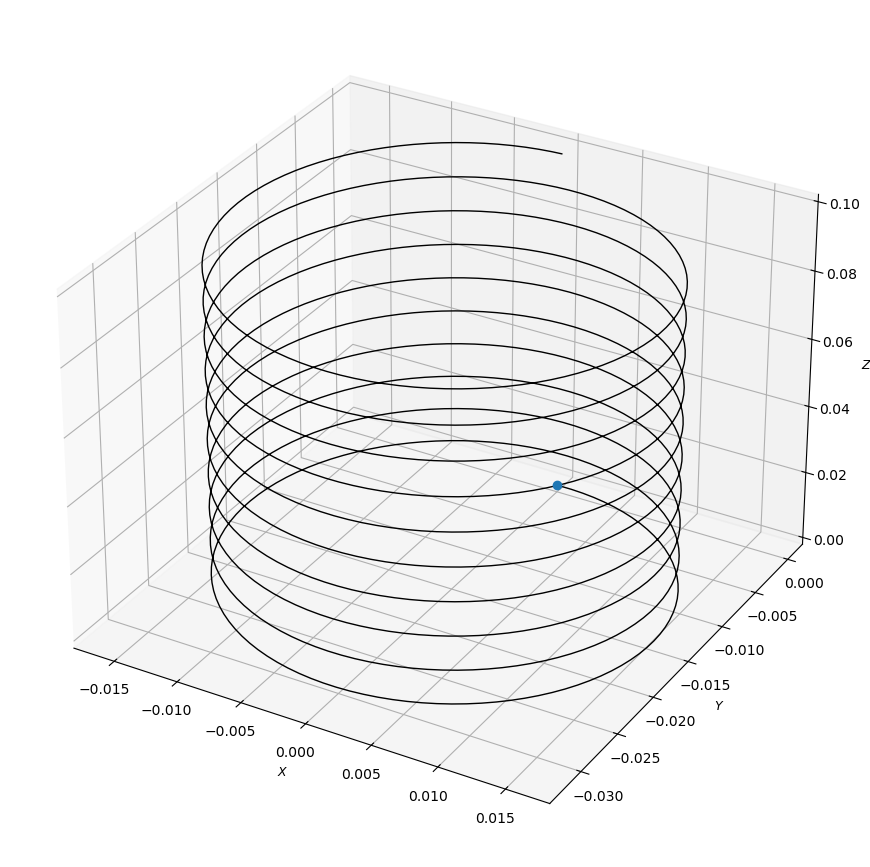

In [ ]:
# Ячейка № 4

# визуализация траектории движения заряда
# в постоянном магнитном поле

fig = plt.figure(figsize=(11, 11))

# инициализация 3-D осей координат
ax = plt.axes(projection="3d")

# построение траектории движения заряда
ax.plot3D(Solv.y[0, :], Solv.y[2, :], Solv.y[4, :], "-k", lw=1)

# визуализация начального положения заряда
ax.plot3D(x0, y0, z0, "o")

ax.set_xlabel(r"$X$", fontsize=9)
ax.set_ylabel(r"$Y$", fontsize=9)
ax.set_zlabel(r"$Z$", fontsize=9)

plt.show()